In [1]:
import argparse
import base64
import io
import random
from typing import List, Optional

import numpy as np
import torch
from datasets import DatasetDict, load_dataset
from diffusers import (AutoencoderKL, DDIMScheduler, DDPMScheduler,
                       UNet2DConditionModel)
from diffusers.image_processor import VaeImageProcessor
from diffusers.utils.torch_utils import randn_tensor
from huggingface_hub import hf_hub_download
from PIL import Image
from safetensors import safe_open
from torchvision import transforms
from tqdm import tqdm
from transformers import CLIPImageProcessor, CLIPTextModel, CLIPTokenizer
import os
from config_sd import BUFFER_SIZE, HEIGHT, REPO_NAME, WIDTH
from sd3.model import get_model

torch.manual_seed(9052924)
np.random.seed(9052924)
random.seed(9052924)

repo_name = "CompVis/stable-diffusion-v1-4"


/Users/pbowmandavis/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:


def read_action_embedding_from_safetensors(file_path: str):
    with safe_open(file_path, framework="pt", device="cpu") as f:
        embedding_weight = f.get_tensor("weight")

    num_embeddings, embedding_dim = embedding_weight.shape
    action_embedding = torch.nn.Embedding(num_embeddings, embedding_dim)
    action_embedding.weight.data = embedding_weight
    return action_embedding


def encode_prompt(
    tokenizer: CLIPTokenizer,
    text_encoder: CLIPTextModel,
    prompts: List[str],
    negative_prompt: List[str],
    batch_size: int,
    device: str,
    do_classifier_free_guidance: bool,
    num_images_per_prompt: int,
):
    assert isinstance(prompts, list), f"Expected list but received: {type(prompts)}"
    text_inputs = tokenizer(
        prompts,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    # NB: the diffusers pipeline is seemingly not using attention_masks for the text encoder
    prompt_embeds = text_encoder(text_inputs.input_ids.to(device))
    prompt_embeds = prompt_embeds[0]

    bs_embed, seq_len, _ = prompt_embeds.shape
    # duplicate text embeddings for each generation per prompt, using mps friendly method
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(bs_embed * num_images_per_prompt, seq_len, -1)

    prompt_embeds_dtype = prompt_embeds.dtype

    if do_classifier_free_guidance:
        uncond_tokens = [""] * batch_size if not negative_prompt else negative_prompt
        uncond_input = tokenizer(
            uncond_tokens,
            padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        negative_prompt_embeds = text_encoder(uncond_input.input_ids.to(device))
        negative_prompt_embeds = negative_prompt_embeds[0]

        seq_len = negative_prompt_embeds.shape[1]

        negative_prompt_embeds = negative_prompt_embeds.to(
            dtype=prompt_embeds_dtype, device=device
        )

        negative_prompt_embeds = negative_prompt_embeds.repeat(
            1, num_images_per_prompt, 1
        )
        negative_prompt_embeds = negative_prompt_embeds.view(
            batch_size * num_images_per_prompt, seq_len, -1
        )

    else:
        negative_prompt_embeds = None

    return prompt_embeds, negative_prompt_embeds


def encode_conditioning_frames(
    vae: AutoencoderKL, conditioning_frames: list[Image.Image], dtype: torch.dtype
):
    conditioning_frames = [
        Image.open(io.BytesIO(base64.b64decode(img))) for img in conditioning_frames
    ]
    transform = transforms.ToTensor()
    conditioning_frames_tensor = torch.stack(
        [transform(image.convert("RGB")) for image in conditioning_frames]
    )
    conditioning_frames = vae.encode(
        conditioning_frames_tensor.to(device=vae.device, dtype=dtype)
    ).latent_dist.sample()
    conditioning_frames = conditioning_frames * vae.config.scaling_factor
    return conditioning_frames


def get_latents(
    noise_scheduler: DDPMScheduler,
    batch_size: int,
    height: int,
    width: int,
    num_channels_latents: int,
    vae_scale_factor: int,
    device: torch.device,
    dtype=torch.float32,
):
    # TODO: here we need to 1) generate a random tensor for the last frame and 2) concatenate the conditioning frames to it

    shape = (
        batch_size,
        num_channels_latents // BUFFER_SIZE,
        int(height) // vae_scale_factor,
        int(width) // vae_scale_factor,
    )
    latents = randn_tensor(shape, generator=None, device=device, dtype=dtype)

    # scale the initial noise by the standard deviation required by the scheduler
    latents = latents * noise_scheduler.init_noise_sigma
    return latents



In [3]:

def run_inference_with_params(
    unet,
    vae,
    noise_scheduler,
    action_embedding,
    tokenizer,
    text_encoder,
    batch,
    device,
    num_inference_steps=30,
    do_classifier_free_guidance=True,
    guidance_scale=7.5,
    skip_image_conditioning=False,
    skip_action_conditioning=True,
):

     # Move all models to the specified device and set to float32
    unet = unet.to(device).to(torch.float32)
    vae = vae.to(device).to(torch.float32)
    action_embedding = action_embedding.to(device).to(torch.float32)
    text_encoder = text_encoder.to(device).to(torch.float32)


    vae_scale_factor = 2 ** (len(vae.config.block_out_channels) - 1)
    image_processor = VaeImageProcessor(vae_scale_factor=vae_scale_factor)
    with torch.no_grad():
        # Modify these lines to work with a single item
        images = batch["pixel_values"].to(device).to(torch.float32)
        actions = batch["input_ids"].to(device)
        if skip_image_conditioning:
            conditioning_frames = None
            batch_size, channels, height, width = images.shape
            #TODO: batched inference, stop hardcoding dimensions
            batch_size=1
            latent_channels=4
            latent_height=64
            latent_width=64
        else:
            # Reshape and encode conditioning frames
            batch_size, buffer_size, channels, height, width = images.shape
            conditioning_frames = images[:, : BUFFER_SIZE - 1].reshape(
                -1, channels, height, width
            )

            conditioning_frames_latents = vae.encode(
                conditioning_frames.to(device)
            ).latent_dist.sample()
            conditioning_frames_latents = (
                conditioning_frames_latents * vae.config.scaling_factor
            )

            # Reshape conditioning_frames_latents back to include batch and buffer dimensions
            _, latent_channels, latent_height, latent_width = (
                conditioning_frames_latents.shape
            )
            conditioning_frames_latents = conditioning_frames_latents.reshape(
                batch_size,
                BUFFER_SIZE - 1,
                latent_channels,
                latent_height,
                latent_width,
            )

        # Generate initial noise for the last frame
        latents = torch.randn(
            (batch_size, latent_channels, latent_height, latent_width), device=device
        )
        latents = latents * noise_scheduler.init_noise_sigma
        print("Initial noise shape: ", latents.shape)
        if not skip_image_conditioning:
            # TODO: gotta figure out whether we want this before or after the conditioning frames
            latents = torch.cat(
                [conditioning_frames_latents, latents.unsqueeze(1)], dim=1
            )

        print("Latents shape after conditioning frames: ", latents.shape)

        # Prepare timesteps
        noise_scheduler.set_timesteps(num_inference_steps, device=device)
        timesteps = noise_scheduler.timesteps

        if not skip_action_conditioning:
            if do_classifier_free_guidance:
                # Not sure what to do for the negative prompt in that case
                encoder_hidden_states = action_embedding(actions.to(device))
            else:
                encoder_hidden_states = action_embedding(actions.to(device))
        else:
            if do_classifier_free_guidance:
                encoder_hidden_states = text_encoder(torch.stack([tokenizer.encode(["doom image, high quality, 4k, high resolution"], return_tensors="pt"), tokenizer.encode(["low quality, low poly, low resolution"], return_tensors="pt")]).to(device))[0]
            else:
                encoder_hidden_states = text_encoder(tokenizer.encode(["doom image, high quality, 4k, high resolution"], return_tensors="pt").to(device))[0]


        latents = latents.view(batch_size, -1, latent_height, latent_width)


        print("Preprocessing complete, latents shape: ", latents.shape)
        # Denoising loop
        for _, t in enumerate(timesteps):
            print("Step ", t)
            latent_model_input = (
                torch.cat([latents] * 2) if do_classifier_free_guidance else latents
            )
            latent_model_input = noise_scheduler.scale_model_input(latent_model_input, t)
            print("latent model input", latent_model_input.shape)
            if not skip_image_conditioning:
                # Predict noise
                noise_pred = unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=encoder_hidden_states,
                    timestep_cond=None,
                    return_dict=False,
                )[0]
                # Perform denoising step on the last frame only
                reshaped_frames = latents.reshape(
                    batch_size,
                    BUFFER_SIZE,
                    latent_channels,
                    latent_height,
                    latent_width,
                )
                last_frame = reshaped_frames[:, -1]
                denoised_last_frame = noise_scheduler.step(
                    noise_pred, t, last_frame, return_dict=False
                )[0]
                reshaped_frames[:, -1] = denoised_last_frame
                latents = reshaped_frames.reshape(
                    batch_size, -1, latent_height, latent_width
                )
                #TODO: unfinished here

            else:
                noise_pred = unet(
                    latent_model_input,
                    t,
                    encoder_hidden_states=encoder_hidden_states,
                    timestep_cond=None,
                    return_dict=False,
                )[0]

                if do_classifier_free_guidance:
                    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                    noise_pred = noise_pred_uncond + guidance_scale * (
                        noise_pred_text - noise_pred_uncond
                    )

                latents = noise_scheduler.step(
                    noise_pred, t, latents, generator=None, return_dict=False
                )[0]

        # Decode the last frame
        image = vae.decode(
            latents / vae.config.scaling_factor, return_dict=False
        )[0]

        # Post-process the image
        image = image_processor.postprocess(
            image.detach(), output_type="pil", do_denormalize=[True] * image.shape[0]
            )
        image[0].save(f"./image_steps{t}.png")

    return image[0]


In [4]:
device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
device="mps"
skip_image_conditioning = False

dataset = load_dataset("P-H-B-D-a16z/ViZDoom-Deathmatch-PPO")
resolution = 512
# Create a train-test split
dataset = dataset["train"].train_test_split(test_size=0.2)

# Create a train-test split
train_test_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

# Create a new DatasetDict with train and test splits
dataset = DatasetDict({
    "train": train_test_dataset["train"],
})

train_transforms = transforms.Compose(
    [
        transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(resolution),
        # transforms.RandomHorizontalFlip() if args.random_flip else transforms.Lambda(lambda x: x),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def preprocess_train(examples):
    # TODO: might need some changes here
    images = []
    for image_list in examples["images"]:
        current_images = []
        image_list = [Image.open(io.BytesIO(base64.b64decode(img))) for img in image_list]
        for image in image_list:
            # TODO: convert to RGB? Should already be
            current_images.append(train_transforms(image))
        images.append(current_images)
    return {"pixel_values": images, "input_ids": [tokenizer.encode("doom image, high quality, 4k, high resolution", return_tensors="pt") for _ in images]}

train_dataset = dataset["train"].with_transform(preprocess_train)
def collate_fn(examples):
    # Function to create a black screen tensor
    def create_black_screen(height, width):
        return torch.zeros(3, height, width, dtype=torch.float32)

    if not skip_image_conditioning:    
        # Process each example
        processed_images = []
        for example in examples:
            
            # This means you have BUFFER_SIZE conditioning frames + 1 target frame
            processed_images.append(torch.stack(example["pixel_values"][:BUFFER_SIZE+1]))

        # Stack all examples
        # images has shape: (batch_size, frame_buffer, 3, height, width)
        images = torch.stack(processed_images)
        images = images.to(memory_format=torch.contiguous_format).float()
    else:
        images = torch.stack([example["pixel_values"][0] for example in examples])
        images = images.to(memory_format=torch.contiguous_format).float()
    return {
        "pixel_values": images,
        "input_ids": torch.stack([example["input_ids"] for example in examples]),
    }
batch_size=4
train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=batch_size,
    num_workers=0,
)

action_dim = max(max(actions) for actions in dataset['train']['actions'])
unet, vae, action_embedding, noise_scheduler, tokenizer, text_encoder = get_model(action_dim, skip_image_conditioning=skip_image_conditioning)


first_batch = next(iter(train_dataloader))

# 5 dimensional: (batch_size, buffer len + 1, channels (3), scaled height =512, scaled width)
print(first_batch['pixel_values'].shape)

/Users/pbowmandavis/Library/Python/3.9/lib/python/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


torch.Size([4, 6, 3, 512, 512])


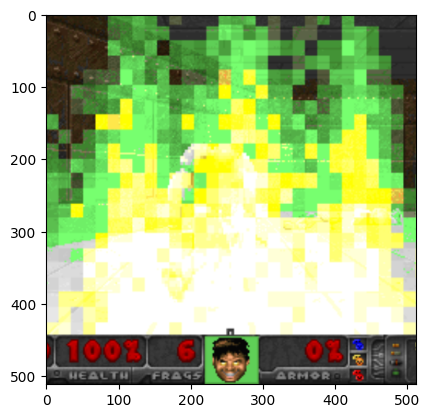

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
#display [0,0,:,:,:] as image 
img = first_batch['pixel_values'][0,0,:,:,:]
img = img.permute(1,2,0).numpy()
img = (img + 1) / 2
img = (img * 255).astype(np.uint8)
#show inline image in jupyter
plt.imshow(img)


In [7]:
run_inference_with_params(
        unet,
        vae,
        noise_scheduler,
        action_embedding,
        tokenizer,
        text_encoder,
        first_batch,
        device,
    )

Initial noise shape:  torch.Size([4, 4, 64, 64])
Latents shape after conditioning frames:  torch.Size([4, 5, 4, 64, 64])
Preprocessing complete, latents shape:  torch.Size([4, 20, 64, 64])
Step  tensor(958, device='mps:0')


RuntimeError: The size of tensor a (16384) must match the size of tensor b (4096) at non-singleton dimension 1